# Exploratory Data Analysis (EDA) for All Four Datasets

This notebook loads the four raw data sources, shows basic statistics, class distribution, missing values, and some visualisations.


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Cài đặt style chung cho seaborn
sns.set_theme(style="whitegrid")



## 1. Load the datasets


In [25]:
# Correct relative path from notebooks/ folder
raw_path = '../data/raw/'
ears_path = raw_path + 'EARS Functional Requirements Complete Dataset.xlsx'
promise_path = raw_path + 'PROMISE-relabeled-NICE.csv'
dcai_path = raw_path + 'dcai24_src_dataset.xlsx'
exp_path = raw_path + 'promise_exp.csv'

ears = pd.read_excel(ears_path)
promise = pd.read_csv(promise_path)
dcai = pd.read_excel(dcai_path)
exp = pd.read_csv(exp_path)

datasets = {'EARS': ears, 'PROMISE': promise, 'DCAI24': dcai, 'PROMISE_EXP': exp}
for name, df in datasets.items():
    print(f'--- {name} ---')
    print('Shape:', df.shape)
    print('Columns:', df.columns.tolist())
    print('Head:', df.head(2).to_dict(orient='list'))
    print('Missing values:', df.isnull().sum().sum())
    print('')


--- EARS ---
Shape: (9677, 6)
Columns: ['Projects', 'Raw Requirements', 'Requiremnet Name', 'EARS Type', 'EARS Requirement', 'Unnamed: 5']
Head: {'Projects': ['PR-01', 'PR-01'], 'Raw Requirements': ['The Game must be developed using the Unity Game Engine', 'The Game must be programmed using the C# language and its libraries compatible with the Unity Engine'], 'Requiremnet Name': ['Game Engine', 'Language'], 'EARS Type': ['ubiquitous', 'ubiquitous'], 'EARS Requirement': ['The game shall be developed using unity game engine', 'The game shall be written in C# and use Unity Engine-compatible libraries.'], 'Unnamed: 5': [nan, nan]}
Missing values: 10696

--- PROMISE ---
Shape: (622, 16)
Columns: ['ProjectID', 'RequirementText', 'IsFunctional', 'IsQuality', 'Availability (A)', 'Fault Tolerance (FT)', 'Legal (L)', 'Look & Feel (LF)', 'Maintainability (MN)', 'Operability (O)', 'Performance (PE)', 'Portability (PO)', 'Scalability (SC)', 'Security (SE)', 'Usability (US)', 'Other (OT)']
Head: {'P

1. PROMISE Dataset EDA

PROMISE Dataset Shape: (622, 16)


,ProjectID,RequirementText,IsFunctional,IsQuality,Availability (A),Fault Tolerance (FT),Legal (L),Look & Feel (LF),Maintainability (MN),Operability (O),Performance (PE),Portability (PO),Scalability (SC),Security (SE),Usability (US),Other (OT)
0,1,'The system shall refresh the display every 60...,1,1,0,0,0,0,0,0,1,0,0,0,0,0
1,1,'The application shall match the color of the ...,0,1,0,0,1,1,0,0,0,0,0,0,0,0
2,1,'If projected the data must be readable. On a ...,0,1,0,0,0,1,0,0,0,0,0,0,1,0


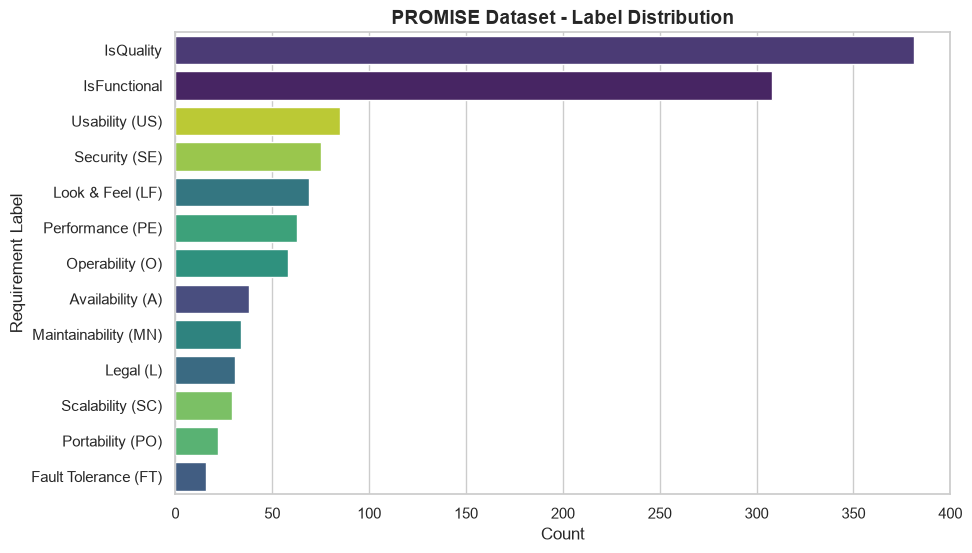

In [26]:
promise_path = '../data/raw/PROMISE-relabeled-NICE.csv'
df_promise = pd.read_csv(promise_path)

print("PROMISE Dataset Shape:", df_promise.shape)
display(df_promise.head(3))

# PROMISE có nhiều cột nhãn (mỗi cột là 0 hoặc 1)
ignore_cols = ['ProjectID', 'RequirementText']
label_cols = [c for c in df_promise.columns if c not in ignore_cols]

# Melt dataframe để đếm tổng bằng countplot
df_promise_melted = df_promise.melt(value_vars=label_cols, var_name='Label', value_name='Present')
df_promise_melted = df_promise_melted[df_promise_melted['Present'] == 1]

plt.figure(figsize=(10, 6))
order = df_promise_melted['Label'].value_counts().index
sns.countplot(data=df_promise_melted, y='Label', order=order, palette="viridis", hue='Label', legend=False)
plt.title('PROMISE Dataset - Label Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Requirement Label')
plt.show()


DCAI24 Dataset Shape: (3482, 5)


,Requirement,Type,Specific_Type,Security_Category,Dataset_Name
0,The system must authenticate users prior to ac...,NFR,SE,Authentication,requirements_MoSCoW'
1,The system must prevent access to applications...,NFR,SE,Authentication,requirements_MoSCoW'
2,The system should provide the ability to imple...,NFR,SE,Authentication,requirements_MoSCoW'


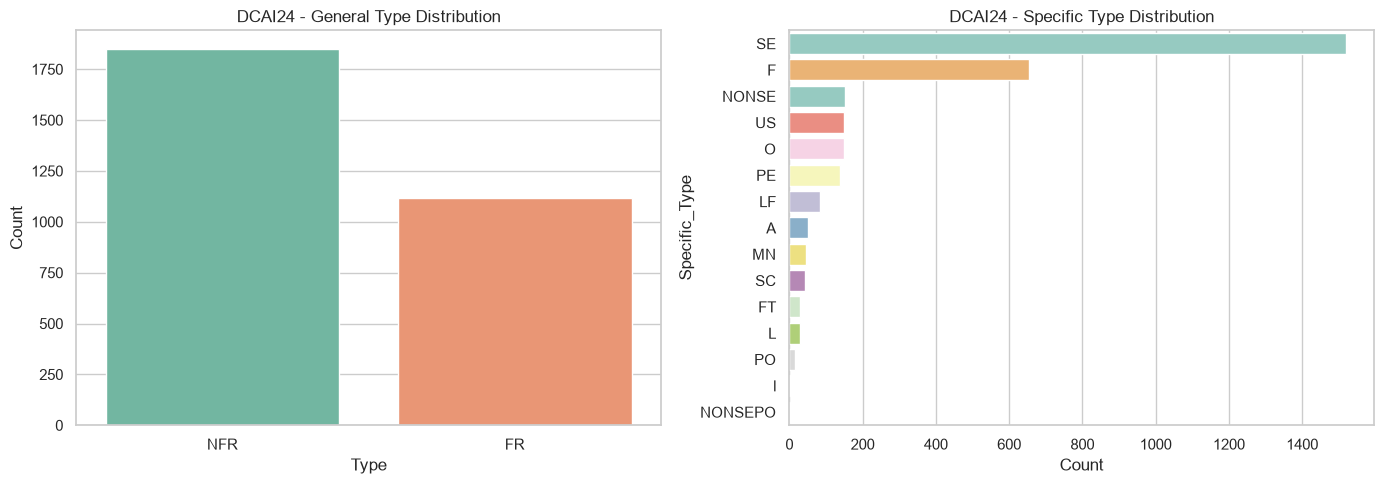

In [27]:
dcai_path = '../data/raw/dcai24_src_dataset.xlsx'
df_dcai = pd.read_excel(dcai_path)

print("DCAI24 Dataset Shape:", df_dcai.shape)
display(df_dcai.head(3))

# Trình bày DCAI24 bằng 2 biểu đồ (Subplots) để thấy được cả Type và Specific_Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_dcai, x='Type', order=df_dcai['Type'].value_counts().index, 
              palette="Set2", hue='Type', legend=False, ax=axes[0])
axes[0].set_title('DCAI24 - General Type Distribution', fontsize=12)
axes[0].set_ylabel('Count')

sns.countplot(data=df_dcai, y='Specific_Type', order=df_dcai['Specific_Type'].value_counts().index, 
              palette="Set3", hue='Specific_Type', legend=False, ax=axes[1])
axes[1].set_title('DCAI24 - Specific Type Distribution', fontsize=12)
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()


EARS Dataset Shape: (9677, 6)


,Projects,Raw Requirements,Requiremnet Name,EARS Type,EARS Requirement,Unnamed: 5
0,PR-01,The Game must be developed using the Unity Gam...,Game Engine,ubiquitous,The game shall be developed using unity game e...,NaN
1,PR-01,The Game must be programmed using the C# langu...,Language,ubiquitous,The game shall be written in C# and use Unity ...,NaN
2,PR-01,The Game must feature accurate sound effects a...,Audio,ubiquitous,The Game shall feature accurate sound effects ...,NaN


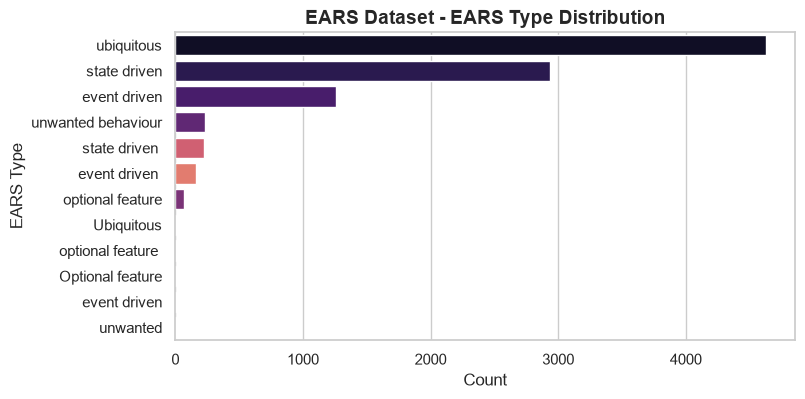

In [28]:
ears_path = '../data/raw/EARS Functional Requirements Complete Dataset.xlsx'
df_ears = pd.read_excel(ears_path)

print("EARS Dataset Shape:", df_ears.shape)
display(df_ears.head(3))

# EARS type distribution (Trình bày thanh ngang với palette magma)
plt.figure(figsize=(8, 4))
order = df_ears['EARS Type'].value_counts().index
sns.countplot(data=df_ears, y='EARS Type', order=order, palette="magma", hue='EARS Type', legend=False)
plt.title('EARS Dataset - EARS Type Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('EARS Type')
plt.show()


PROMISE_EXP Dataset Shape: (969, 3)


,ProjectID,RequirementText,class
0,1,The system shall refresh the display every 60 ...,PE
1,1,The application shall match the color of the s...,LF
2,1,If projected the data must be readable. On a...,US


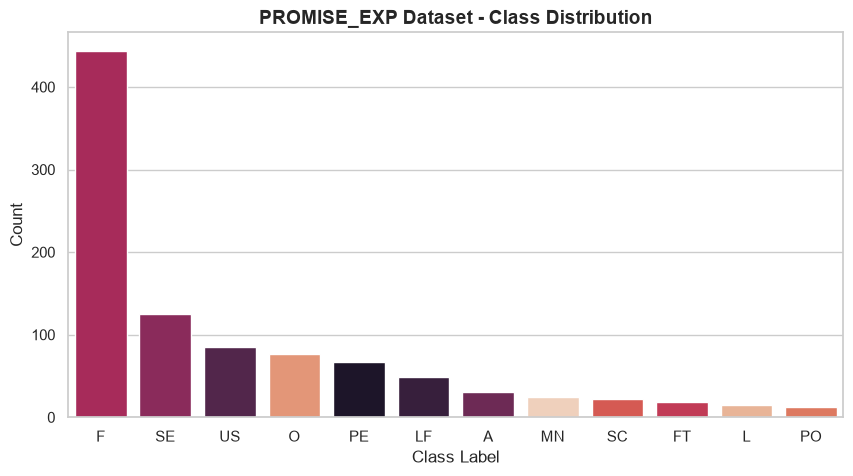

In [29]:
exp_path = '../data/raw/promise_exp.csv'
df_exp = pd.read_csv(exp_path)

print("PROMISE_EXP Dataset Shape:", df_exp.shape)
display(df_exp.head(3))

# PROMISE_EXP class distribution (Trình bày thanh dọc với palette rocket)
plt.figure(figsize=(10, 5))
order = df_exp['class'].value_counts().index
sns.countplot(data=df_exp, x='class', order=order, palette="rocket", hue='class', legend=False)
plt.title('PROMISE_EXP Dataset - Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.show()
